Sending request to start the SD1.5 + LoRA job...
Job successfully started with ID: 9a9c3824-e3fc-43e7-b45d-da3e7363ba20-u2
Polling for job status... (attempt 1)
Polling for job status... (attempt 2)
Polling for job status... (attempt 3)
Polling for job status... (attempt 4)
Polling for job status... (attempt 5)
Polling for job status... (attempt 6)
Polling for job status... (attempt 7)
Job completed successfully!

Image successfully generated and saved as 'ComfyUI_SD15_00001_.png'



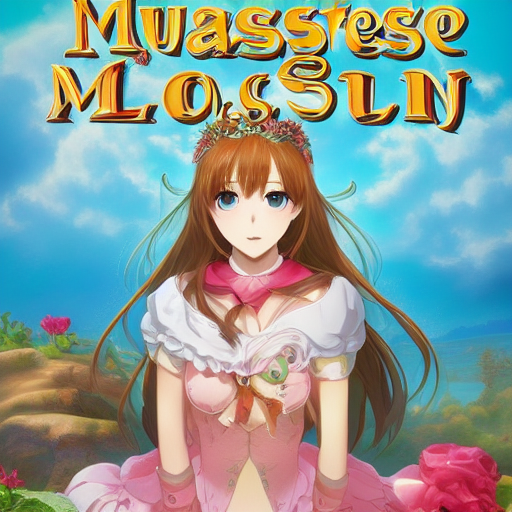

In [1]:
import requests
import base64
import json
import time
from PIL import Image
from io import BytesIO
from dotenv import load_dotenv 
import os

# --- 1. Configuration ---
load_dotenv()

api_key = os.getenv("RUNPOD_API_KEY")
if not api_key:
    raise ValueError("API key not found. Please create a .env file and add RUNPOD_API_KEY=your_key")

endpoint_id = os.getenv("RUNPOD_ENDPOINT_ID", "a48mrbdsbzg35n")

# --- 2. Define the API URLs ---
run_url = f"https://api.runpod.ai/v2/{endpoint_id}/run"
status_url_template = f"https://api.runpod.ai/v2/{endpoint_id}/status/"

# --- 3. Define the SD1.5 + LoRA Workflow Payload ---
sd15_workflow = {
    "input": {
        "workflow": {
            "3": {
                "inputs": {
                    "seed": int(time.time() * 1000) % (2**32),  # Random seed
                    "steps": 20,
                    "cfg": 8,
                    "sampler_name": "euler",
                    "scheduler": "normal",
                    "denoise": 1,
                    "model": ["10", 0],
                    "positive": ["6", 0],
                    "negative": ["7", 0],
                    "latent_image": ["5", 0]
                },
                "class_type": "KSampler",
                "_meta": {
                    "title": "KSampler"
                }
            },
            "4": {
                "inputs": {
                    "ckpt_name": "v1-5-pruned-emaonly.ckpt"
                },
                "class_type": "CheckpointLoaderSimple",
                "_meta": {
                    "title": "Load Checkpoint"
                }
            },
            "5": {
                "inputs": {
                    "width": 512,
                    "height": 512,
                    "batch_size": 1
                },
                "class_type": "EmptyLatentImage",
                "_meta": {
                    "title": "Empty Latent Image"
                }
            },
            "6": {
                "inputs": {
                    "text": "masterpiece best quality girl",
                    "clip": ["10", 1]
                },
                "class_type": "CLIPTextEncode",
                "_meta": {
                    "title": "CLIP Text Encode (Prompt)"
                }
            },
            "7": {
                "inputs": {
                    "text": "bad hands",
                    "clip": ["10", 1]
                },
                "class_type": "CLIPTextEncode",
                "_meta": {
                    "title": "CLIP Text Encode (Prompt)"
                }
            },
            "8": {
                "inputs": {
                    "samples": ["3", 0],
                    "vae": ["4", 2]
                },
                "class_type": "VAEDecode",
                "_meta": {
                    "title": "VAE Decode"
                }
            },
            "9": {
                "inputs": {
                    "filename_prefix": "ComfyUI_SD15",
                    "images": ["8", 0]
                },
                "class_type": "SaveImage",
                "_meta": {
                    "title": "Save Image"
                }
            },
            "10": {
                "inputs": {
                    "lora_name": "epiNoiseoffset_v2.safetensors",
                    "strength_model": 1,
                    "strength_clip": 1,
                    "model": ["4", 0],
                    "clip": ["4", 1]
                },
                "class_type": "LoraLoader",
                "_meta": {
                    "title": "Load LoRA"
                }
            }
        }
    }
}

# --- 4. Send the Initial API Request to Start the Job ---
headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

print("Sending request to start the SD1.5 + LoRA job...")
response = requests.post(run_url, headers=headers, json=sd15_workflow)

if response.status_code == 200:
    response_data = response.json()
    job_id = response_data.get('id')
    
    if not job_id:
        print("Error: API response did not include a job ID.")
        print("Full response:", json.dumps(response_data, indent=2))
    else:
        print(f"Job successfully started with ID: {job_id}")

        # --- 5. Poll for the Job Status ---
        status_url = status_url_template + job_id
        poll_count = 0
        max_polls = 120  # 10 minutes max (5 second intervals)
        
        while poll_count < max_polls:
            print(f"Polling for job status... (attempt {poll_count + 1})")
            status_response = requests.get(status_url, headers=headers)
            status_data = status_response.json()
            job_status = status_data.get('status')

            if job_status == 'COMPLETED':
                print("Job completed successfully!")
                
                # --- 6. Process the Final Output ---
                try:
                    output_image_data = status_data['output']['images'][0]
                    image_base64 = output_image_data['data'] 
                    filename = output_image_data['filename']

                    image_bytes = base64.b64decode(image_base64)
                    image = Image.open(BytesIO(image_bytes))
                    
                    image.save(filename)
                    print(f"\nImage successfully generated and saved as '{filename}'\n")
                    
                    # Display the image in the notebook
                    from IPython.display import display
                    display(image)

                except (KeyError, IndexError, TypeError) as e:
                    print(f"\nError: Could not parse image data from the final response: {e}\n")
                    
                    debug_data = json.loads(json.dumps(status_data))
                    try:
                        for img in debug_data['output']['images']:
                            if 'data' in img:
                                original_length = len(img['data'])
                                img['data'] = f"<base64 data redacted, original length: {original_length}>"
                    except Exception:
                        pass 
                        
                    print("Full response (redacted):", json.dumps(debug_data, indent=2))
                
                break

            elif job_status in ['IN_QUEUE', 'IN_PROGRESS']:
                time.sleep(5)
                poll_count += 1
            else:
                print(f"Job execution failed or was cancelled.")
                print("Final Status:", job_status)
                if 'error' in status_data:
                    print("Error details:", status_data['error'])
                else:
                    print("Full response:", json.dumps(status_data, indent=2))
                break 
        
        if poll_count >= max_polls:
            print("Timeout: Job did not complete within the expected time.")

else:
    print(f"Error: Initial API request failed with status code {response.status_code}")
    print("Response:", response.text)